# Signal study for Run3 Monotop


Using monorot signal NanoAOD directly or NOT scaled `.scaled` file from coffea processor.   
Files are merged with `hadd -f Vector_Monotop_Mphi....root /path/to/sig/nano.root`.

In [1]:
import hist
from coffea.util import load, save
import mplhep as hep
import matplotlib.pyplot as plt
import copy
import numpy as np
import os
from tabulate import tabulate
import uncertainties as unc  
import uncertainties.unumpy as unumpy 
plt.style.use(hep.style.CMS)

### Using scaled file to histogram

In [19]:
hists = load('./hadmonotopsignaltestv2.scaled')

In [20]:
hists

{'bkg': {'sumw': {},
  'cutflow': {},
  'j1pt': {},
  'j1eta': {},
  'j1phi': {},
  'fj1pt': {},
  'fj1eta': {},
  'fj1phi': {},
  'mT': {},
  'met': {},
  'metphi': {},
  'njets': {},
  'nfjets': {}},
 'sig': {'sumw': {'sig_Mphi-1995_Mchi-1000': 1439.6411,
   'sig_Mphi-2000_Mchi-1500': 1439.6411,
   'sig_Mphi-2000_Mchi-500': 1439.6411,
   'sig_Mphi-2000_Mchi-150': 1439.6411},
  'cutflow': {'sig_Mphi-1995_Mchi-1000': Hist(
     StrCategory([], growth=True, name='region'),
     StrCategory([], growth=True, name='cutname'),
     Variable([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], name='cutflow', label='cut'),
     storage=Weight()) # Sum: WeightedSum(value=0, variance=0),
   'sig_Mphi-2000_Mchi-1500': Hist(
     StrCategory([], growth=True, name='region'),
     StrCategory([], growth=True, name='cutname'),
     Variable([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], name='cutflow', label='cut'),
     storage=Weight()) # Sum: WeightedSum(value=0, vari

In [21]:
sig_hists = hists['sig']

In [22]:
sig_hists

{'sumw': {'sig_Mphi-1995_Mchi-1000': 1439.6411,
  'sig_Mphi-2000_Mchi-1500': 1439.6411,
  'sig_Mphi-2000_Mchi-500': 1439.6411,
  'sig_Mphi-2000_Mchi-150': 1439.6411},
 'cutflow': {'sig_Mphi-1995_Mchi-1000': Hist(
    StrCategory([], growth=True, name='region'),
    StrCategory([], growth=True, name='cutname'),
    Variable([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], name='cutflow', label='cut'),
    storage=Weight()) # Sum: WeightedSum(value=0, variance=0),
  'sig_Mphi-2000_Mchi-1500': Hist(
    StrCategory([], growth=True, name='region'),
    StrCategory([], growth=True, name='cutname'),
    Variable([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], name='cutflow', label='cut'),
    storage=Weight()) # Sum: WeightedSum(value=0, variance=0),
  'sig_Mphi-2000_Mchi-500': Hist(
    StrCategory([], growth=True, name='region'),
    StrCategory([], growth=True, name='cutname'),
    Variable([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], name

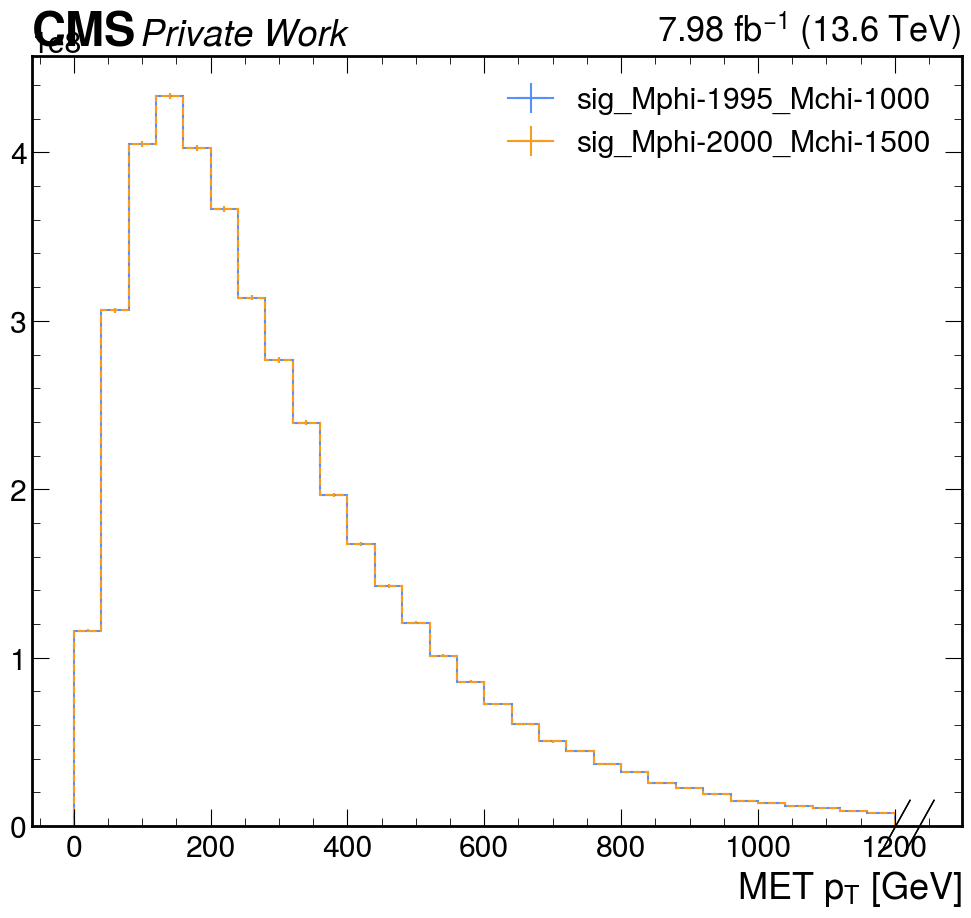

In [33]:
####
## myntuple draw
####
year = '2022'
lumi = {
    '2022': 7.98
}
region = 'sr'
vari = 'met'
sig_hists = hists['sig']
#nevent = sig_hists[vari]
#print(nevent)
plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(12,10),
)

stack_hists = []
labels = []
hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13.6 TeV)')
nocode = '''
for k in sig_hists[vari].keys():
    print(k)
    no_stack = sig_hists[vari][k][{'region': region}]

    #stack_hists.append(one_stack)
    no_stack.plot(ax=ax, label=k)
    #labels.append(k)
'''
h1 = sig_hists[vari]['sig_Mphi-1995_Mchi-1000'][{'region': region}]
h2 = sig_hists[vari]['sig_Mphi-2000_Mchi-1500'][{'region': region}]
h3 = sig_hists[vari]['sig_Mphi-2000_Mchi-500'][{'region': region}]
h4 = sig_hists[vari]['sig_Mphi-2000_Mchi-150'][{'region': region}]

h1.plot(ax=ax, label='sig_Mphi-1995_Mchi-1000')
h2.plot(ax=ax, label='sig_Mphi-2000_Mchi-1500', linestyle='--')
#stack_obj = hist.Stack(*stack_hists)

#stack_obj.plot(stack=True, ax=ax, label=labels)

#ax.set_xlim(0,2000)
ax.legend()
#ax.set_ylim(0.01,1000000)
#ax.set_yscale('log')
plt.show()
#plt.savefig('./egmNTuple_recoil.png')

### Using root file with using uproot

In [5]:
import uproot
import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt
import os, sys


In [45]:
r1 = uproot.open("merged_sig_nano_22/Vector_Monotop_Mphi-1995_Mchi-1000_2022.root")

In [46]:
r1tree = r1["Events"]
variables = [
    "MET_pt", "MET_phi", 
    'AK15Puppi_pt', 'AK15Puppi_phi'
]

In [47]:
r1tree.keys()

['run',
 'luminosityBlock',
 'event',
 'bunchCrossing',
 'HTXS_njets25',
 'HTXS_njets30',
 'HTXS_stage1_1_cat_pTjet25GeV',
 'HTXS_stage1_1_cat_pTjet30GeV',
 'HTXS_stage1_1_fine_cat_pTjet25GeV',
 'HTXS_stage1_1_fine_cat_pTjet30GeV',
 'HTXS_stage1_2_cat_pTjet25GeV',
 'HTXS_stage1_2_cat_pTjet30GeV',
 'HTXS_stage1_2_fine_cat_pTjet25GeV',
 'HTXS_stage1_2_fine_cat_pTjet30GeV',
 'HTXS_stage_0',
 'HTXS_stage_1_pTjet25',
 'HTXS_stage_1_pTjet30',
 'HTXS_Higgs_pt',
 'HTXS_Higgs_y',
 'nAK15PuppiSubJet',
 'AK15PuppiSubJet_nBHadrons',
 'AK15PuppiSubJet_nCHadrons',
 'AK15PuppiSubJet_area',
 'AK15PuppiSubJet_eta',
 'AK15PuppiSubJet_mass',
 'AK15PuppiSubJet_phi',
 'AK15PuppiSubJet_pt',
 'AK15PuppiSubJet_rawFactor',
 'nAK15Puppi',
 'AK15Puppi_jetId',
 'AK15Puppi_nBHadrons',
 'AK15Puppi_nCHadrons',
 'AK15Puppi_subJetIdx1',
 'AK15Puppi_subJetIdx2',
 'AK15Puppi_ParT_probHbb',
 'AK15Puppi_ParT_probHbc',
 'AK15Puppi_ParT_probHbs',
 'AK15Puppi_ParT_probHcc',
 'AK15Puppi_ParT_probHcs',
 'AK15Puppi_ParT_probHee

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(exptext: Custom Text(0.0, 1, 'CMS'),
 expsuffix: Custom Text(0.0, 1.005, 'Private Work'),
 supptext: Custom Text(1.012, 1, ''))

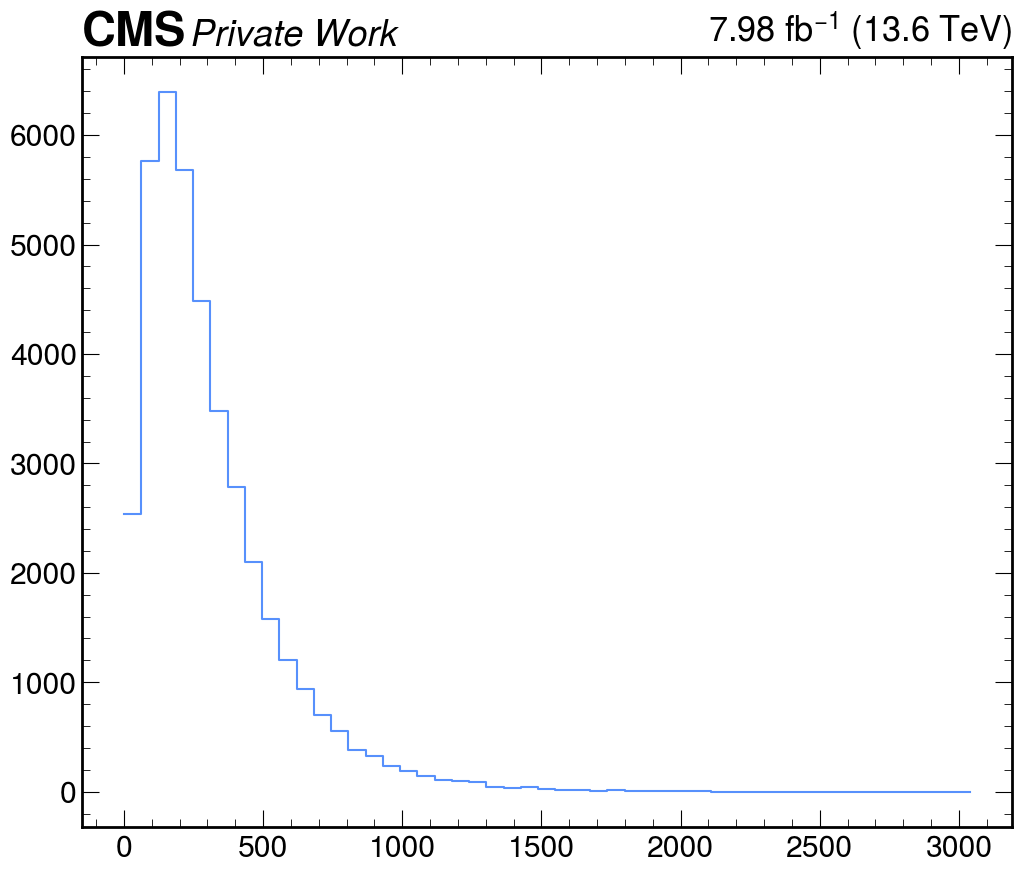

In [58]:
metpt = r1tree["MET_pt"].array(library="ak")
#arr = ak.to_numpy(ak.flatten(metpt))
hist, edges = np.histogram(metpt, bins=bins)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(12,10),
)
plt.legend()
plt.step(edges[:-1], hist, where="post", label="mphi")
stack_hists = []
labels = []
hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13.6 TeV)')
#metpt.plot(ax=ax, label='sig_Mphi-1995_Mchi-1000')

## Plotting signal kinematics (three root files)

In [12]:
root_files = [
    "/mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-1995_Mchi-1000_2022.root",
    "/mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-1500_2022.root",
#    "/mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-150_2022.root",
#    "/mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-1750_Mchi-150_2022.root",
#    "/mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2500_Mchi-150_2022.root",
    "/mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-750_2022.root",
    "/mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-500_2022.root",
    "/mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-3000_Mchi-150_2022.root",

    "/mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-250_2022.root"
]
def read_branch(rootfile, branch):
    with uproot.open(rootfile) as f:
        arr = f['Events'][branch].array(library="ak")
        if 'MET' in branch:
            return ak.to_numpy(arr)
        else:
            return ak.to_numpy(ak.flatten(arr))
        #return ak.to_numpy(ak.flatten(arr))
        #return ak.to_numpy(arr)

In [13]:
def plot_overlay(files, var, bins=50, outname=None):
    plt.figure(figsize=(12,10))
    plt.style.use(hep.style.CMS)
    #hep.cms.label(llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13.6 TeV)')
    hep.cms.label(llabel='Private Work', rlabel=' 13.6 TeV')

    for f in files:
        try:
            vals = read_branch(f, var)
        except Exception as e:
            print(f"[WARN] cannot read {f}: {e}")
            continue

        hist, edges = np.histogram(vals, bins=bins)
        #plt.step(edges[:-1], hist, where="post", label=f"{f.split('/')[-1].split('.')[0].split('Vector_Monotop_')[-1].split('_2022')[0]} ")
        plt.hist(vals, range=(0,2000), bins=bins, histtype='step', linewidth=2.5, label=f"{f.split('/')[-1].split('.')[0].split('Vector_Monotop_')[-1].split('_2022')[0]}")

    
    plt.xlabel(var)
    plt.yscale('log')
    plt.ylabel("Entries")
    if 'MET_pt' in var:
        plt.xlim(0, 2000)
    #plt.title(f"{var} overlay")
    plt.grid(alpha=0.4)
    plt.legend()
    plt.tight_layout()

    if outname is None:
        outname = f"{var}_Medmass_log.png"

    plt.savefig(outname, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved → {outname}")

[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-750_2022.root: not found: 'MET_pt'

    Available keys: 'event', 'run', 'luminosityBlock', 'bunchCrossing'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-750_2022.root
in object /Events;1
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-3000_Mchi-150_2022.root: not found: 'MET_pt'

    Available keys: 'event', 'run', 'luminosityBlock', 'bunchCrossing'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-3000_Mchi-150_2022.root
in object /Events;1
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-250_2022.root: not found: 'MET_pt'

    Available keys: 'event', 'run', 'luminosityBlock', 'bunchCrossing'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-250_2022.root
in object /Events;1


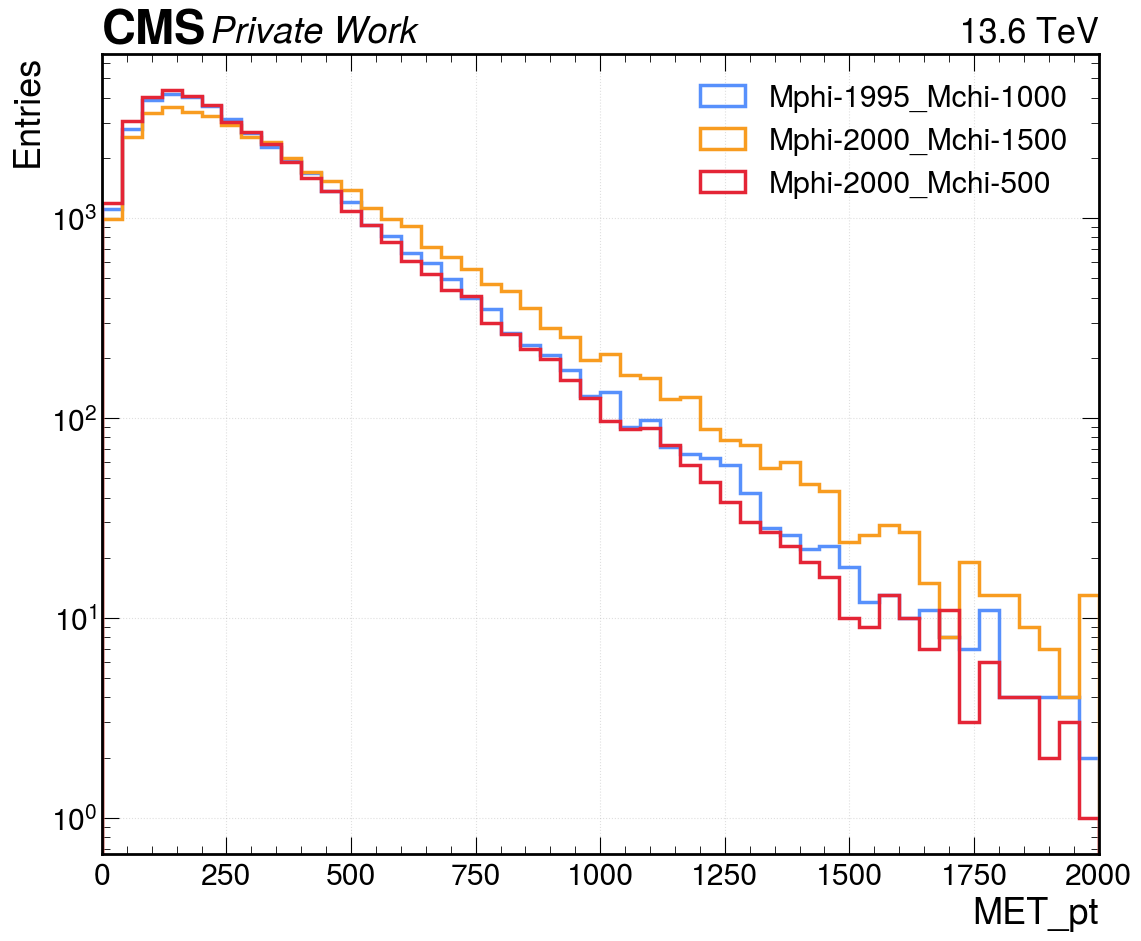

Saved → MET_pt_Med2000_log_
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-750_2022.root: not found: 'MET_phi'

    Available keys: 'event', 'run', 'bunchCrossing', 'luminosityBlock'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-750_2022.root
in object /Events;1
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-3000_Mchi-150_2022.root: not found: 'MET_phi'

    Available keys: 'event', 'run', 'bunchCrossing', 'luminosityBlock'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-3000_Mchi-150_2022.root
in object /Events;1
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-250_2022.root: not found: 'MET_phi'

    Available keys: 'event', 'run', 'bunchCrossing', 'luminosityBlock'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-250_

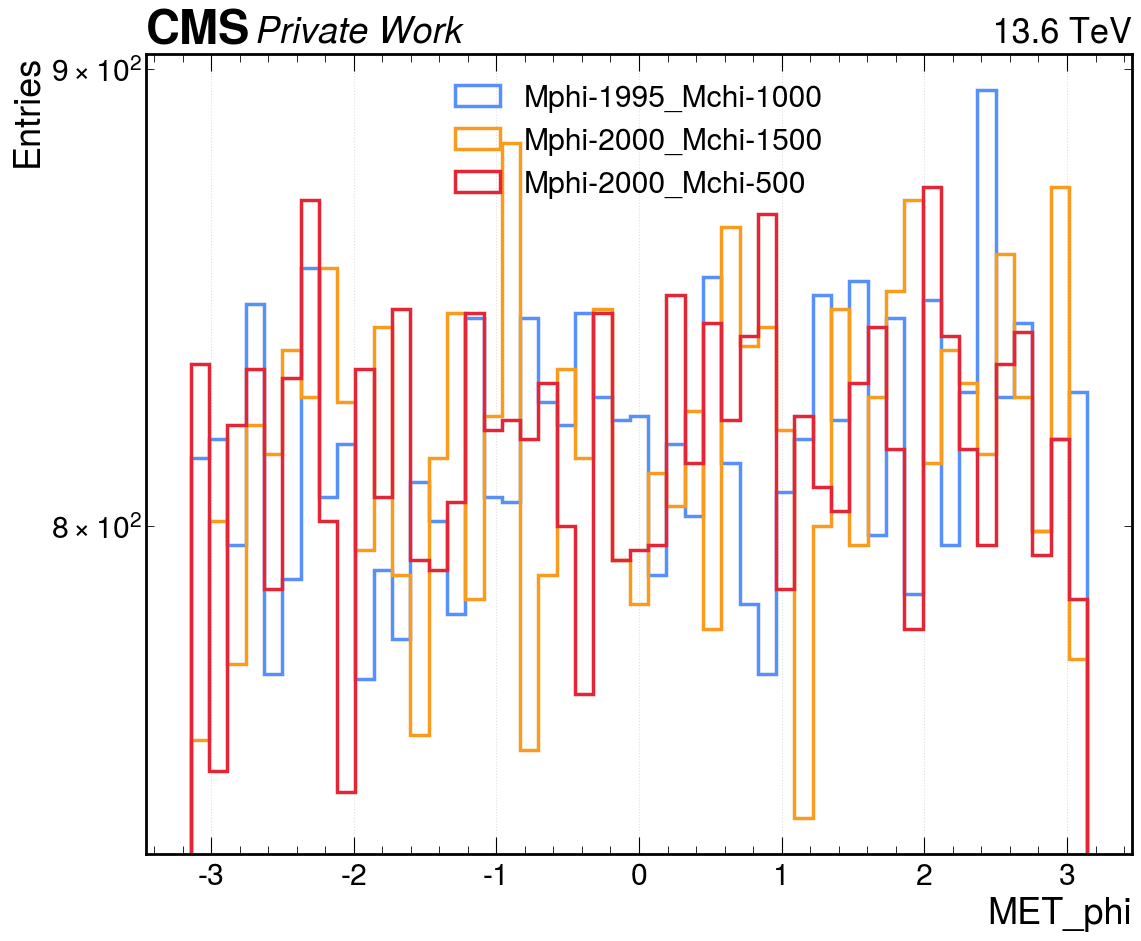

Saved → MET_phi_Med2000_log_
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-750_2022.root: not found: 'AK15Puppi_pt'

    Available keys: 'run', 'event', 'luminosityBlock', 'bunchCrossing'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-750_2022.root
in object /Events;1
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-3000_Mchi-150_2022.root: not found: 'AK15Puppi_pt'

    Available keys: 'run', 'event', 'luminosityBlock', 'bunchCrossing'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-3000_Mchi-150_2022.root
in object /Events;1
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-250_2022.root: not found: 'AK15Puppi_pt'

    Available keys: 'run', 'event', 'luminosityBlock', 'bunchCrossing'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mph

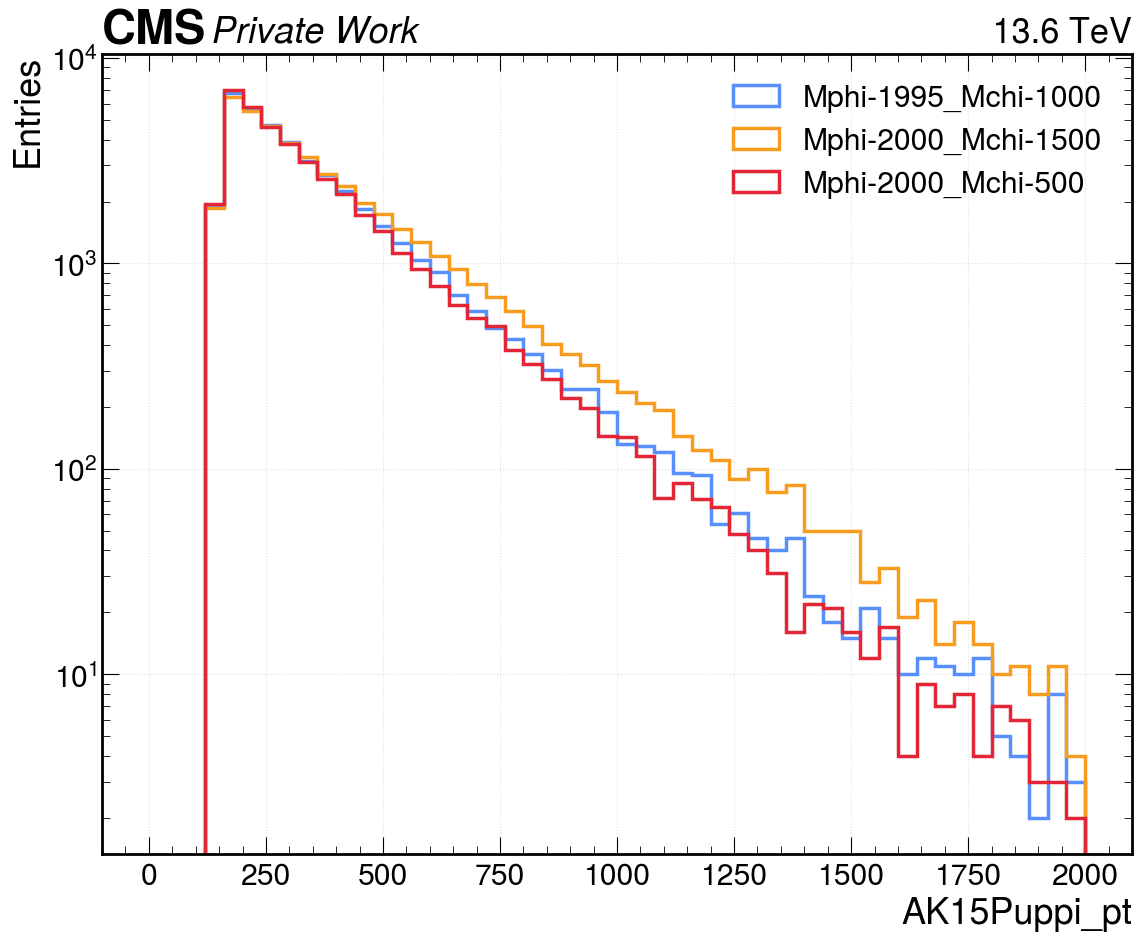

Saved → AK15Puppi_pt_Med2000_log_
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-750_2022.root: not found: 'AK15Puppi_phi'

    Available keys: 'run', 'event', 'bunchCrossing', 'luminosityBlock'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-750_2022.root
in object /Events;1
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-3000_Mchi-150_2022.root: not found: 'AK15Puppi_phi'

    Available keys: 'run', 'event', 'bunchCrossing', 'luminosityBlock'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-3000_Mchi-150_2022.root
in object /Events;1
[WARN] cannot read /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-2000_Mchi-250_2022.root: not found: 'AK15Puppi_phi'

    Available keys: 'run', 'event', 'bunchCrossing', 'luminosityBlock'

in file /mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Mon

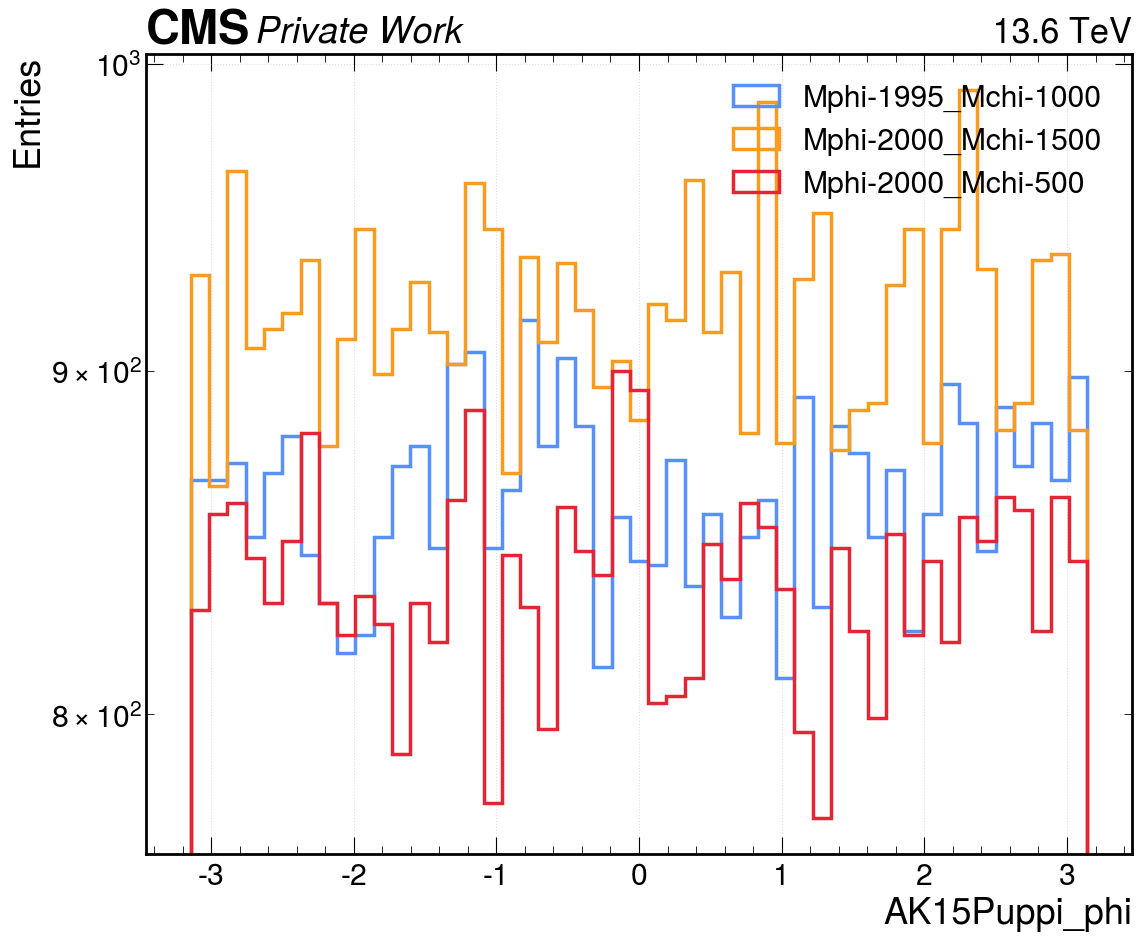

Saved → AK15Puppi_phi_Med2000_log_


In [14]:
variables = [
    "MET_pt", "MET_phi", 
    'AK15Puppi_pt', 'AK15Puppi_phi'
]

for var in variables:
    outname = f"{var}_Med2000_log_"
    if "phi" in var:
        bins = np.linspace(-np.pi, np.pi, 50)
    else:
        bins = 50

    plot_overlay(root_files,  var, bins=bins, outname=outname)

## Applying Coupling

The custom reweight card information is stored `LHEReweightingWeight` branch in NanoAOD.    
In NanoAOD, the reweight values are stored just numbers. The orders are same with reweight_card.   
Index is read from `reweight_card`.

In [142]:
## Read rwgt_name from reweight crad
## Keep the order
mtop_coupling = []
with open("/mnt/mydisk/work2T/mTop_sig_2022/Vector_MonoTop_reweight_card.dat") as f:
    for line in f:
        line = line.strip()
        if line.startswith("launch --rwgt_name="):
            name = line.split("launch --rwgt_name=")[1]
            mtop_coupling.append(name)

for i in range(len(mtop_coupling)):
    print(mtop_coupling[i])

gdmv_0p1_gdma_0_gv_0p25_ga_0
gdmv_0p25_gdma_0_gv_0p25_ga_0
gdmv_0p5_gdma_0_gv_0p25_ga_0
gdmv_1p0_gdma_0_gv_0p1_ga_0
gdmv_1p0_gdma_0_gv_0p5_ga_0
gdmv_1p0_gdma_0_gv_1_ga_0
gdmv_2p0_gdma_0_gv_0p25_ga_0
gdmv_0_gdma_0p1_gv_0_ga_0p25
gdmv_0_gdma_0p25_gv_0_ga_0p25
gdmv_0_gdma_0p5_gv_0_ga_0p25
gdmv_0_gdma_1p0_gv_0_ga_0p1
gdmv_0_gdma_1p0_gv_0_ga_0p25
gdmv_0_gdma_1p0_gv_0_ga_0p5
gdmv_0_gdma_1p0_gv_0_ga_1
gdmv_0_gdma_2p0_gv_0_ga_0p25
gdmv_0p05_gdma_0p05_gv_0p05_ga_0p05
gdmv_0p05_gdma_0p05_gv_0p125_ga_0p125
gdmv_0p05_gdma_0p05_gv_0p25_ga_0p25
gdmv_0p05_gdma_0p05_gv_0p5_ga_0p5
gdmv_0p05_gdma_0p05_gv_1p0_ga_1p0
gdmv_0p125_gdma_0p125_gv_0p05_ga_0p05
gdmv_0p125_gdma_0p125_gv_0p125_ga_0p125
gdmv_0p125_gdma_0p125_gv_0p25_ga_0p25
gdmv_0p125_gdma_0p125_gv_0p5_ga_0p5
gdmv_0p125_gdma_0p125_gv_1p0_ga_1p0
gdmv_0p25_gdma_0p25_gv_0p05_ga_0p05
gdmv_0p25_gdma_0p25_gv_0p125_ga_0p125
gdmv_0p25_gdma_0p25_gv_0p25_ga_0p25
gdmv_0p25_gdma_0p25_gv_0p5_ga_0p5
gdmv_0p25_gdma_0p25_gv_1p0_ga_1p0
gdmv_0p5_gdma_0p5_gv_0p05_ga_

In [138]:
## Read root file
root_files = [

    "/mnt/mydisk/work2T/mTop_sig_2022/merged_sig_nano_22/Vector_Monotop_Mphi-1245_Mchi-625_2022.root",

]
def read_branch(rootfile, branch):
    with uproot.open(rootfile) as f:
        arr = f['Events'][branch].array(library="ak")
        if 'MET' in branch or 'LHE' in branch:Coupling
            return ak.to_numpy(arr)
        else:
            return ak.to_numpy(ak.flatten(arr))

In [126]:
mycoupling = read_branch(root_files[0], "LHEReweightingWeight")
myMET = read_branch(root_files[0], "MET_pt")

In [127]:
print(mycoupling, len(mycoupling))
print(myMET, len(myMET))

[[1.00312233e-02 6.26869202e-02 2.50640869e-01 ... 7.36840820e+00
  2.77167969e+01 6.49570312e+01]
 [3.57379913e-02 2.05795288e-01 6.21795654e-01 ... 8.48419189e-01
  6.61804199e-01 2.51037598e-01]
 [1.17425919e-02 7.29713440e-02 2.85125732e-01 ... 3.89850140e-03
  5.21254539e-03 2.34436989e-03]
 ...
 [2.06909180e-02 1.24889374e-01 4.37820435e-01 ... 1.20483398e+00
  1.02105713e+00 3.94790649e-01]
 [1.34248734e-02 8.29620361e-02 3.17184448e-01 ... 3.91723633e+00
  4.19165039e+00 1.73114014e+00]
 [1.48000717e-02 9.10491943e-02 3.42117310e-01 ... 5.78796387e-01
  5.67291260e-01 2.28019714e-01]] 40000
[ 67.19465 513.9115  320.64108 ... 425.1832   98.35086  90.68865] 40000


In [131]:
## Check numbers of reweighting
for i in range(len(mycoupling)):
    print(mycoupling[i]) #, len(mycoupling[i]))
    if i > 4:
        break

[1.0031223e-02 6.2686920e-02 2.5064087e-01 1.6036224e-01 3.9365234e+00
 1.3261719e+01 3.9044189e+00 8.9850426e-03 5.6150436e-02 2.2451019e-01
 1.4365387e-01 8.9584351e-01 3.5272217e+00 1.1889160e+01 3.5025635e+00
 7.4794888e-04 4.6739578e-03 1.8646240e-02 7.1575165e-02 1.7401886e-01
 4.6746731e-03 2.9211044e-02 1.1652756e-01 4.4717407e-01 1.0866089e+00
 1.8698692e-02 1.1683273e-01 4.6594238e-01 1.7863159e+00 4.3325195e+00
 7.4768066e-02 4.6704102e-01 1.8606567e+00 7.1054688e+00 1.7106445e+01
 2.9763794e-01 1.8570557e+00 7.3684082e+00 2.7716797e+01 6.4957031e+01]
[3.5737991e-02 2.0579529e-01 6.2179565e-01 3.3474731e-01 8.4597778e-01
 3.2810974e-01 6.0034180e-01 3.4242630e-02 1.9772339e-01 6.0269165e-01
 3.3561707e-01 9.9093628e-01 8.2357788e-01 3.1584167e-01 6.0809326e-01
 2.6527643e-03 1.2273312e-02 9.9568367e-03 2.9060841e-03 7.3489547e-04
 1.6413689e-02 7.3913574e-02 6.0440063e-02 1.8009186e-02 4.5831203e-03
 6.1759949e-02 2.5715637e-01 2.1844482e-01 6.9892883e-02 1.8192291e-02
 1.50

In [135]:
selected_weight = mycoupling[:, 1]

In [136]:
print(selected_weight, len(selected_weight))

[0.06268692 0.20579529 0.07297134 ... 0.12488937 0.08296204 0.09104919] 40000


In [180]:
## Store indices from mtop coupling
index_only_vector = []
index_only_axial  = []
index_gdm_0p05  = []
index_gdm_0p125 = []
index_gdm_0p25  = []
index_gdm_0p5   = []

for i in range(len(mtop_coupling)):
    
    if 'gdma_0_' in mtop_coupling[i] and mtop_coupling[i].split('_')[-1] == '0':
        index_only_vector.append(i)
        
    if 'gdmv_0_' in mtop_coupling[i] and '_gv_0_' in mtop_coupling[i]:
        index_only_axial.append(i)

    if 'gdmv_0p05_gdma_0p05_' in mtop_coupling[i]:
        index_gdm_0p05.append(i)
        
    if 'gdmv_0p125_gdma_0p125_' in mtop_coupling[i]:
        index_gdm_0p125.append(i)
        
    if 'gdmv_0p25_gdma_0p25_' in mtop_coupling[i]:
        index_gdm_0p25.append(i)
        
    if 'gdmv_0p5_gdma_0p5_' in mtop_coupling[i]:
        #print(i,', ',mtop_coupling[i])
        index_gdm_0p5.append(i)

30 ,  gdmv_0p5_gdma_0p5_gv_0p05_ga_0p05
31 ,  gdmv_0p5_gdma_0p5_gv_0p125_ga_0p125
32 ,  gdmv_0p5_gdma_0p5_gv_0p25_ga_0p25
33 ,  gdmv_0p5_gdma_0p5_gv_0p5_ga_0p5
34 ,  gdmv_0p5_gdma_0p5_gv_1p0_ga_1p0


In [263]:
color_list = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf",
    "#aec7e8", "#ffbb78", "#98df8a", "#ff9896",
    "#c5b0d5", "#c49c94", "#f7b6d2", "#c7c7c7",
    "#dbdb8d", "#9edae5"
]

def plot_overlay_reweight(files, var, weight_indices, weight_names=None, bins=50, islog=False, outname=None):
    plt.figure(figsize=(10,10))
    plt.style.use(hep.style.CMS)
    #hep.cms.label(llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13.6 TeV)')
    hep.cms.label(llabel='Private Work', rlabel=' 13.6 TeV')

    for f in files:
        try:
            vals = read_branch(f, var)
            weights_vals = read_branch(f, "LHEReweightingWeight")
        except Exception as e:
            print(f"[WARN] cannot read {f}: {e}")
            continue

        sig_title = f"{f.split('/')[-1].split('.')[0].split('Vector_Monotop_')[-1].split('_2022')[0]}"

        for i, idx in enumerate(weight_indices):

            weight = weights_vals[:, idx]
            label_name = mtop_coupling[idx]
            color = color_list[i % len(color_list)]

            hist, edges = np.histogram(vals, bins=bins)
            #plt.step(edges[:-1], hist, where="post", label=f"{f.split('/')[-1].split('.')[0].split('Vector_Monotop_')[-1].split('_2022')[0]} ")
            plt.hist(vals, range=(0,2000), bins=bins, histtype='step', weights=weight, label=label_name, color=color, linewidth=2.5)
        
        hist, edges = np.histogram(vals, bins=bins)
        plt.hist(vals, range=(0,2000), bins=bins, histtype='step', label="gdmv_1p0_gdma_0_gv_0p25_ga_0 (nominal)", linewidth=2.5, linestyle='--', color='black')
        


    
    plt.xlabel(var)
    #plt.ylim(0.01, 20000)
    if islog:
        plt.yscale('log')
        plt.ylim(0.01, 25000)
    plt.ylabel("Entries", loc='center')
    if 'MET_pt' in var:
        plt.xlim(0, 1000)
    #plt.title(f"{sig_title}", fontsize=20)
    plt.grid(alpha=0.4)
    
    plt.legend(fontsize=16)
    plt.text(0.65, 0.15, f"{sig_title}", transform=plt.gca().transAxes, fontsize=18, bbox=dict(facecolor='yellow', alpha=0.6, edgecolor='black'))
    plt.tight_layout()

    if outname is None:
        outname = f"{var}_coupling.png"

    plt.savefig(outname, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved → {outname}")

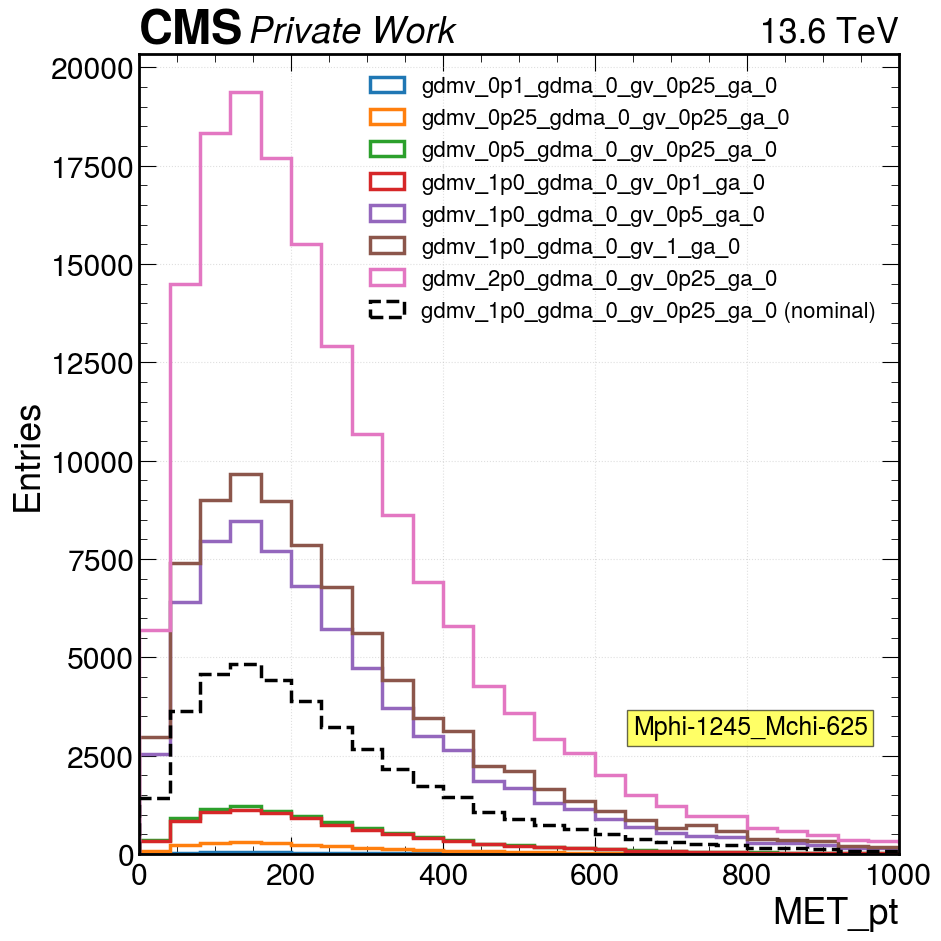

Saved → Mphi-1245_Mchi-625_only_vector.png


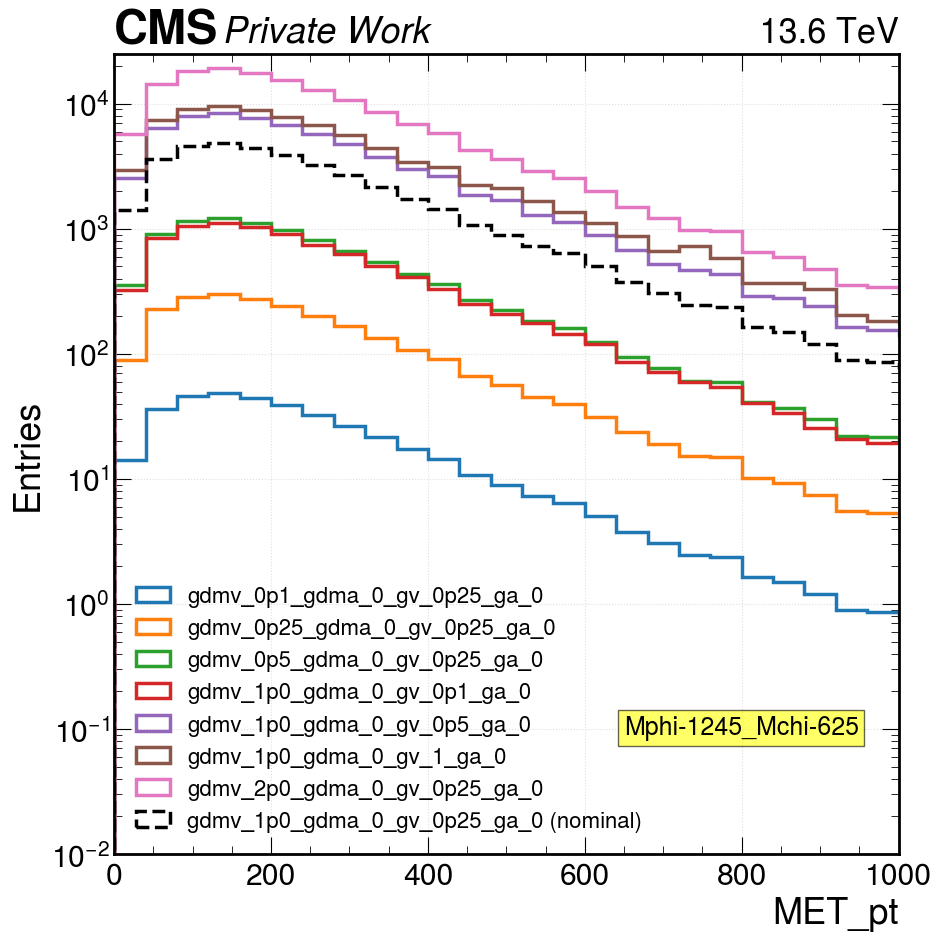

Saved → Mphi-1245_Mchi-625_only_vector_log.png


In [264]:
vari = "MET_pt"
plot_overlay_reweight(root_files, vari, index_only_vector, mtop_coupling, islog=False, outname="Mphi-1245_Mchi-625_only_vector.png")
plot_overlay_reweight(root_files, vari, index_only_vector, mtop_coupling, islog=True, outname="Mphi-1245_Mchi-625_only_vector_log.png")

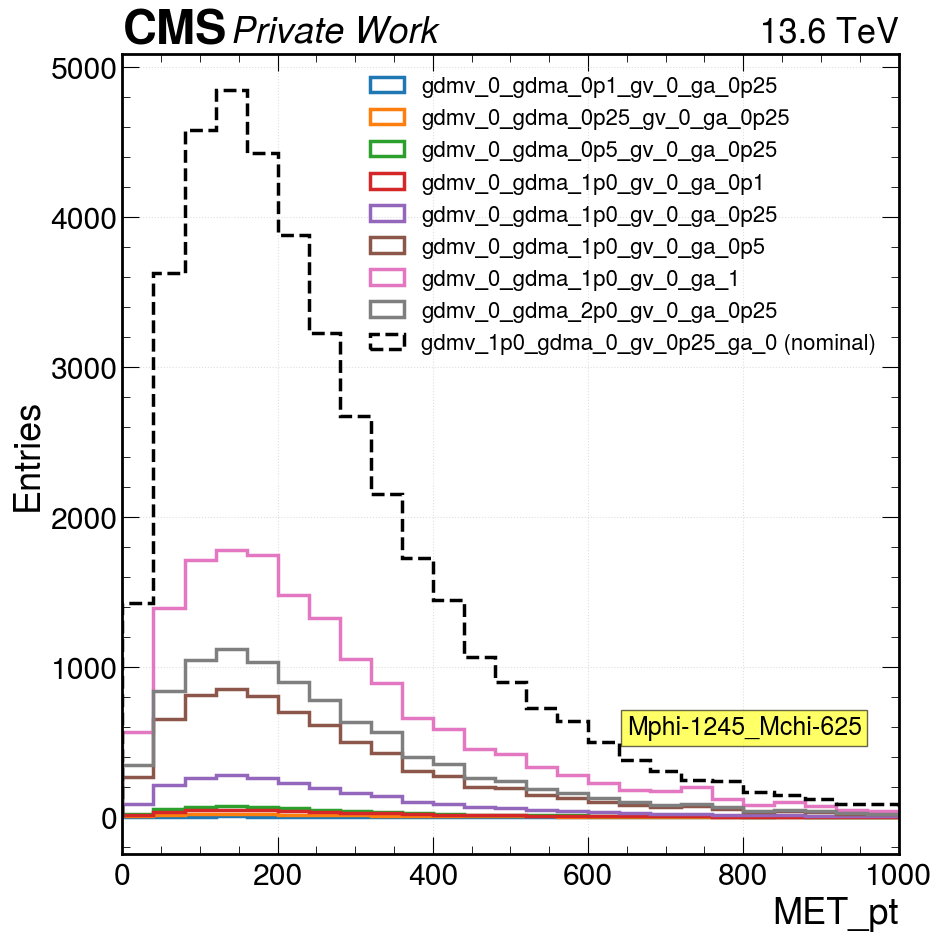

Saved → Mphi-1245_Mchi-625_only_axial.png


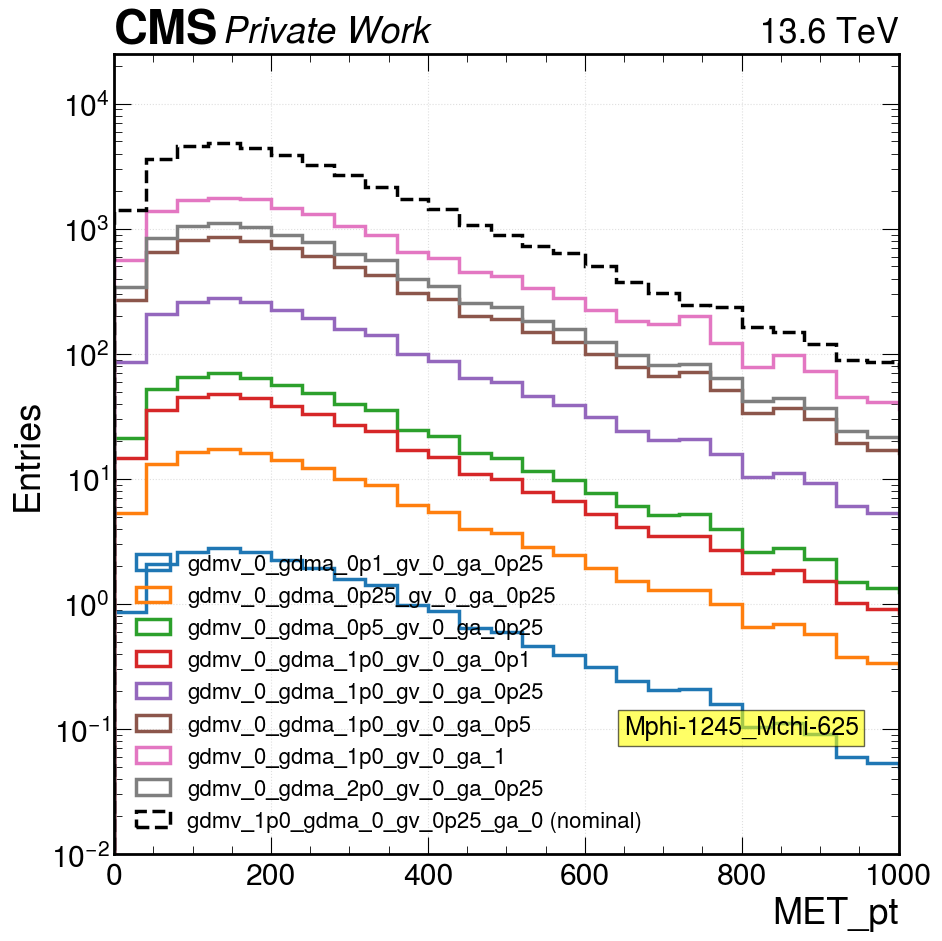

Saved → Mphi-1245_Mchi-625_only_axial_log.png


In [265]:
vari = "MET_pt"
what_couple = 'only_axial'
plot_overlay_reweight(root_files, vari, index_only_axial, mtop_coupling, islog=False, outname=f"Mphi-1245_Mchi-625_{what_couple}.png")
plot_overlay_reweight(root_files, vari, index_only_axial, mtop_coupling, islog=True, outname=f"Mphi-1245_Mchi-625_{what_couple}_log.png")

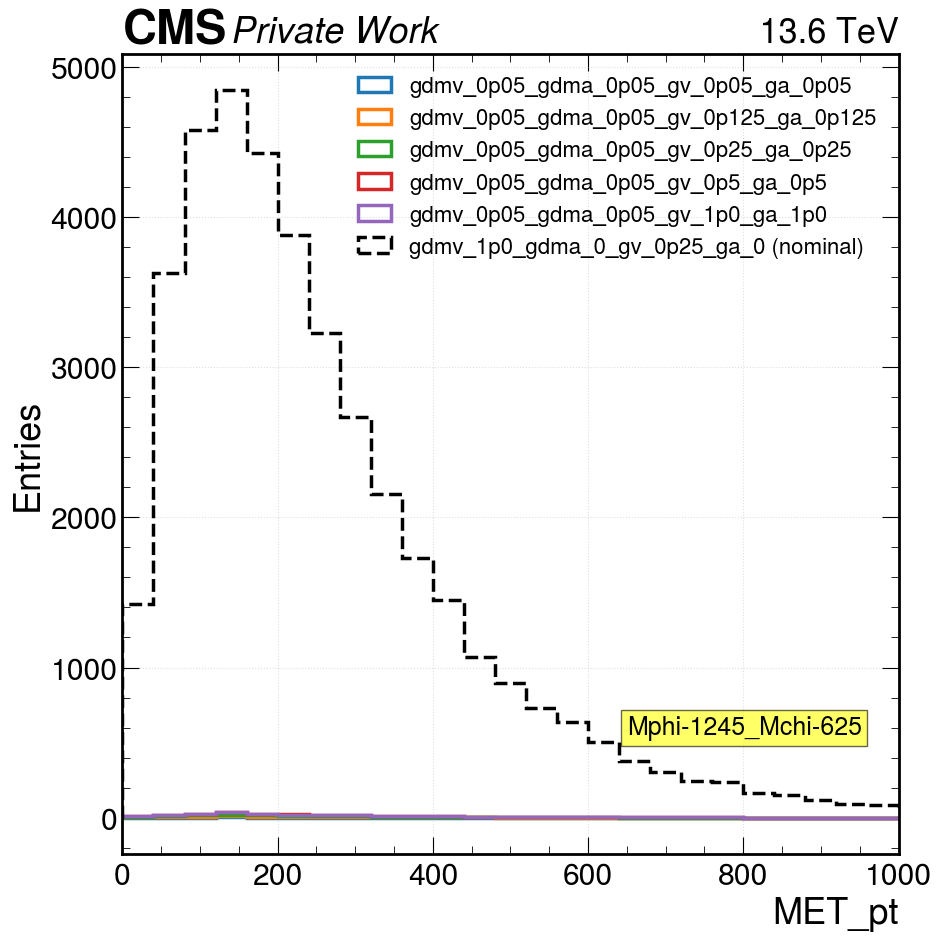

Saved → Mphi-1245_Mchi-625_gdm_0p05.png


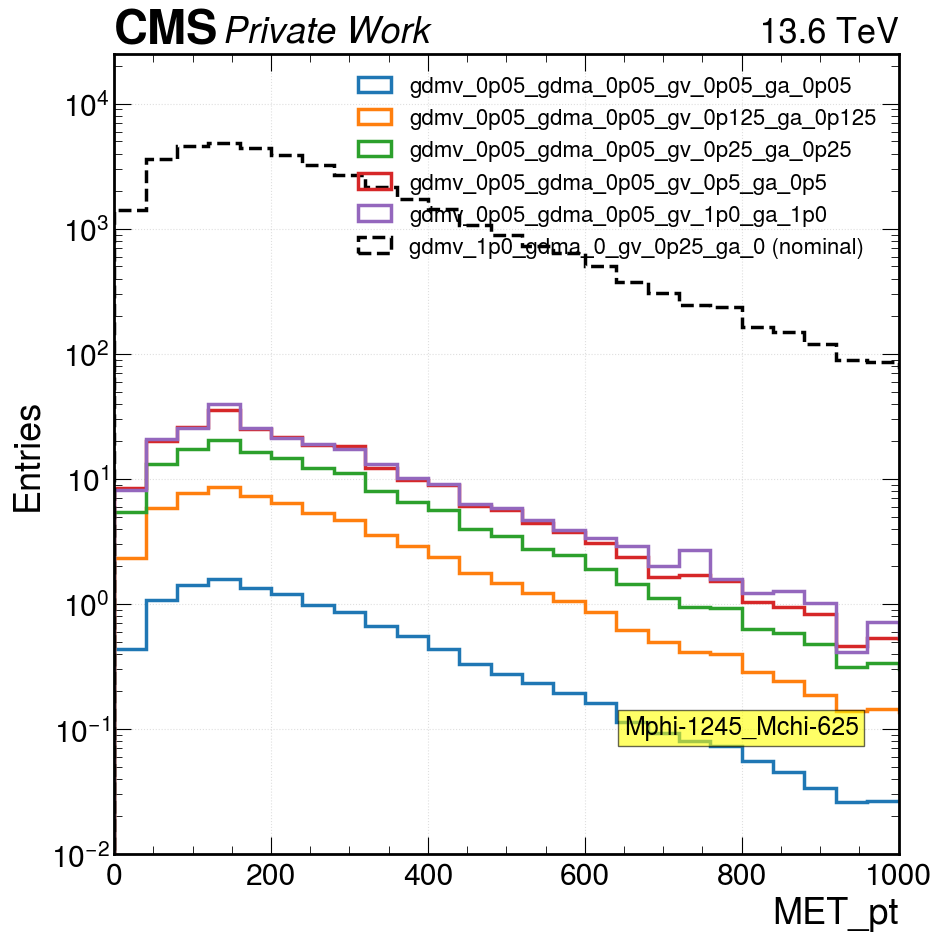

Saved → Mphi-1245_Mchi-625_gdm_0p05_log.png


In [266]:
vari = "MET_pt"
what_couple = 'gdm_0p05'
plot_overlay_reweight(root_files, vari, index_gdm_0p05, mtop_coupling, islog=False, outname=f"Mphi-1245_Mchi-625_{what_couple}.png")
plot_overlay_reweight(root_files, vari, index_gdm_0p05, mtop_coupling, islog=True, outname=f"Mphi-1245_Mchi-625_{what_couple}_log.png")

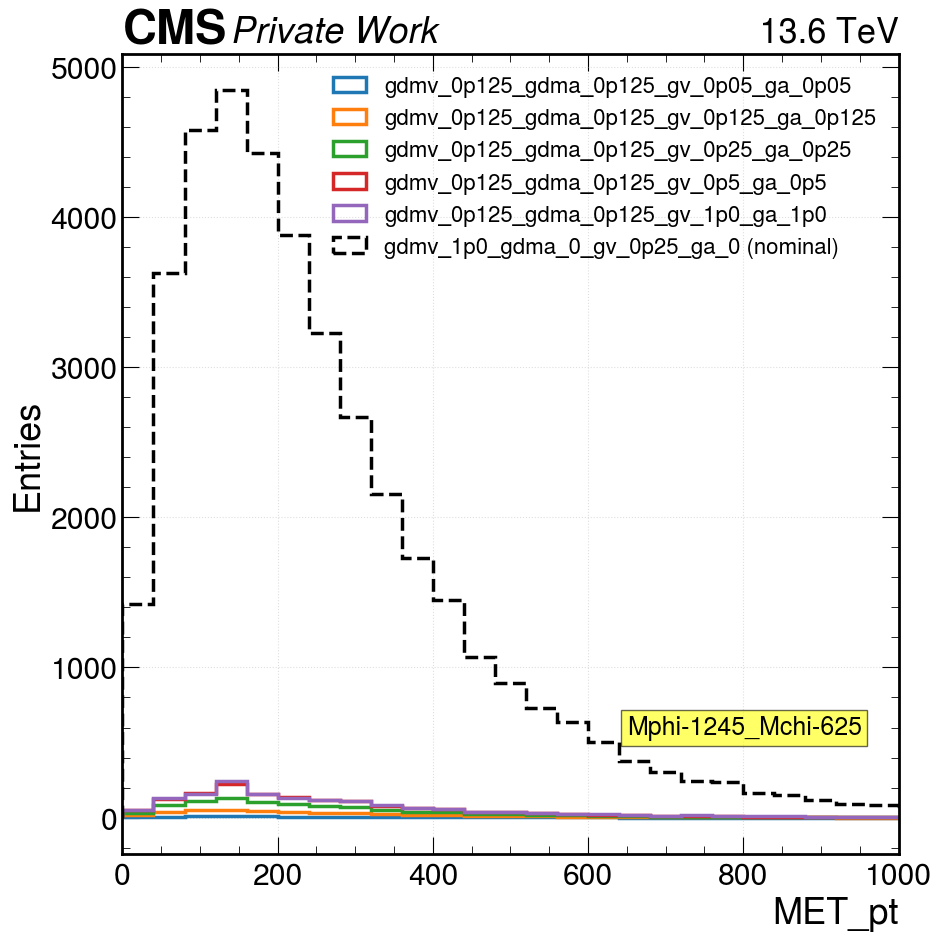

Saved → Mphi-1245_Mchi-625_gdm_0p125.png


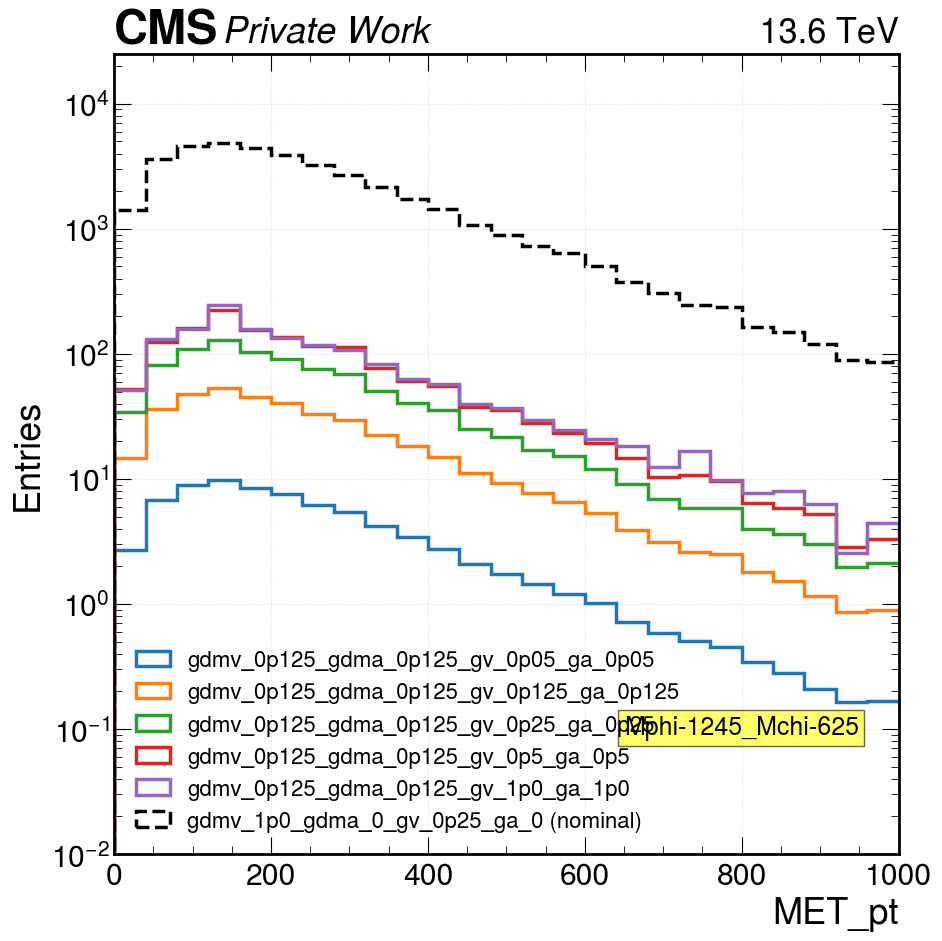

Saved → Mphi-1245_Mchi-625_gdm_0p125_log.png


In [267]:
vari = "MET_pt"
what_couple = 'gdm_0p125'
plot_overlay_reweight(root_files, vari, index_gdm_0p125, mtop_coupling, islog=False, outname=f"Mphi-1245_Mchi-625_{what_couple}.png")
plot_overlay_reweight(root_files, vari, index_gdm_0p125, mtop_coupling, islog=True, outname=f"Mphi-1245_Mchi-625_{what_couple}_log.png")

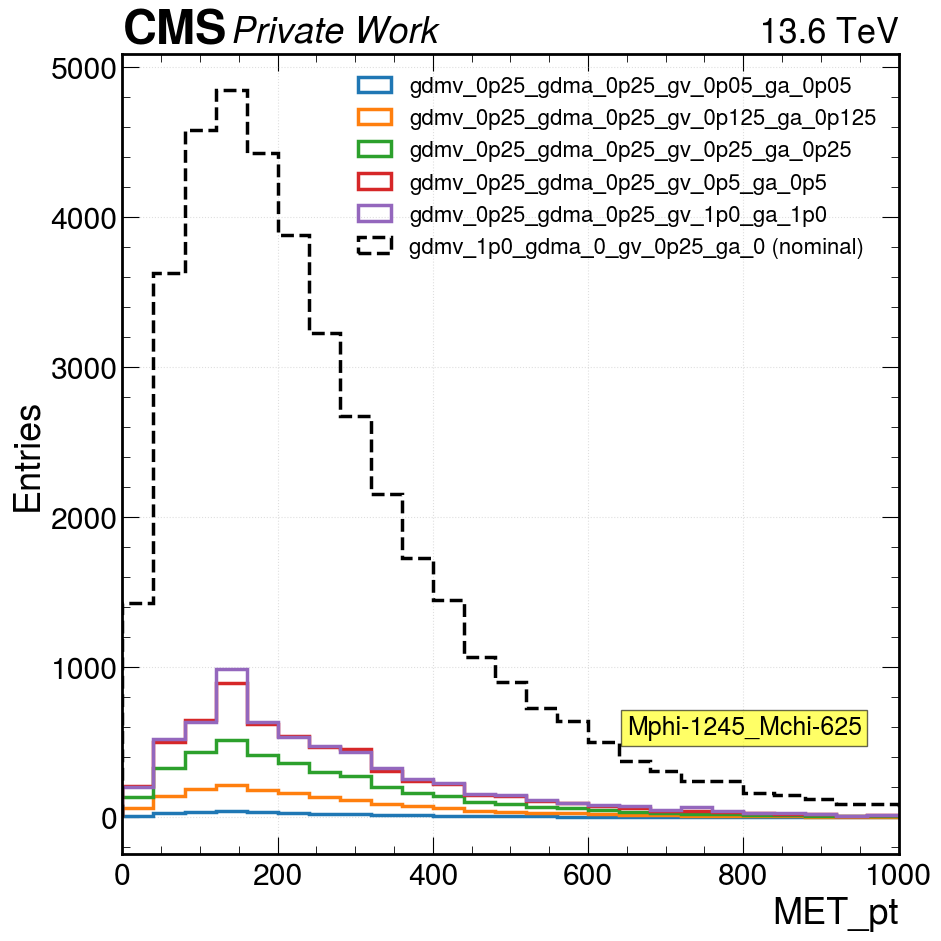

Saved → Mphi-1245_Mchi-625_gdm_0p25.png


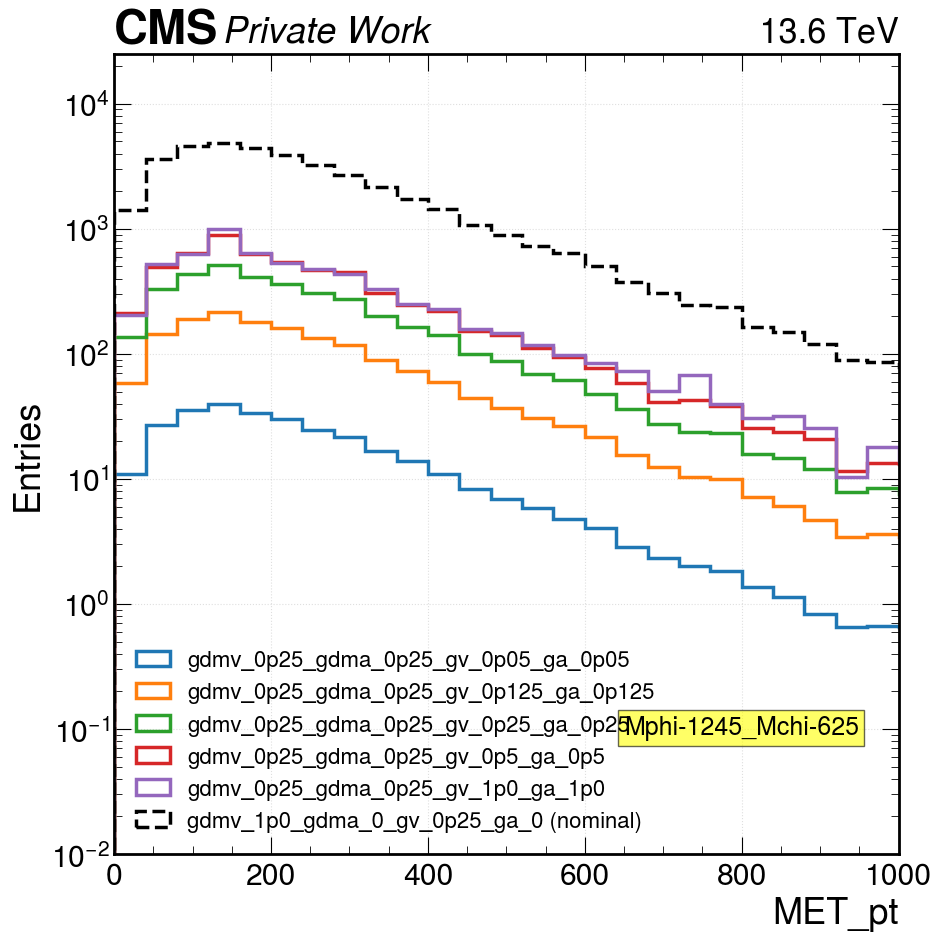

Saved → Mphi-1245_Mchi-625_gdm_0p25_log.png


In [268]:
vari = "MET_pt"
what_couple = 'gdm_0p25'
plot_overlay_reweight(root_files, vari, index_gdm_0p25, mtop_coupling, islog=False, outname=f"Mphi-1245_Mchi-625_{what_couple}.png")
plot_overlay_reweight(root_files, vari, index_gdm_0p25, mtop_coupling, islog=True, outname=f"Mphi-1245_Mchi-625_{what_couple}_log.png")

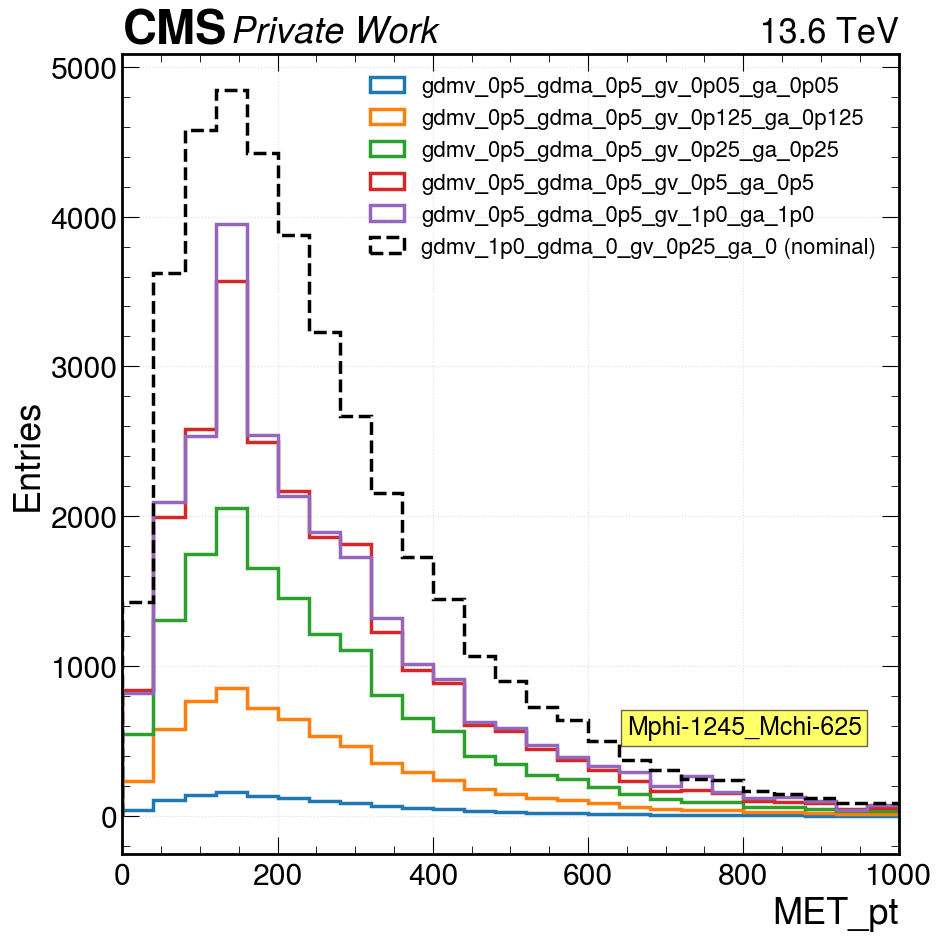

Saved → Mphi-1245_Mchi-625_gdm_0p5.png


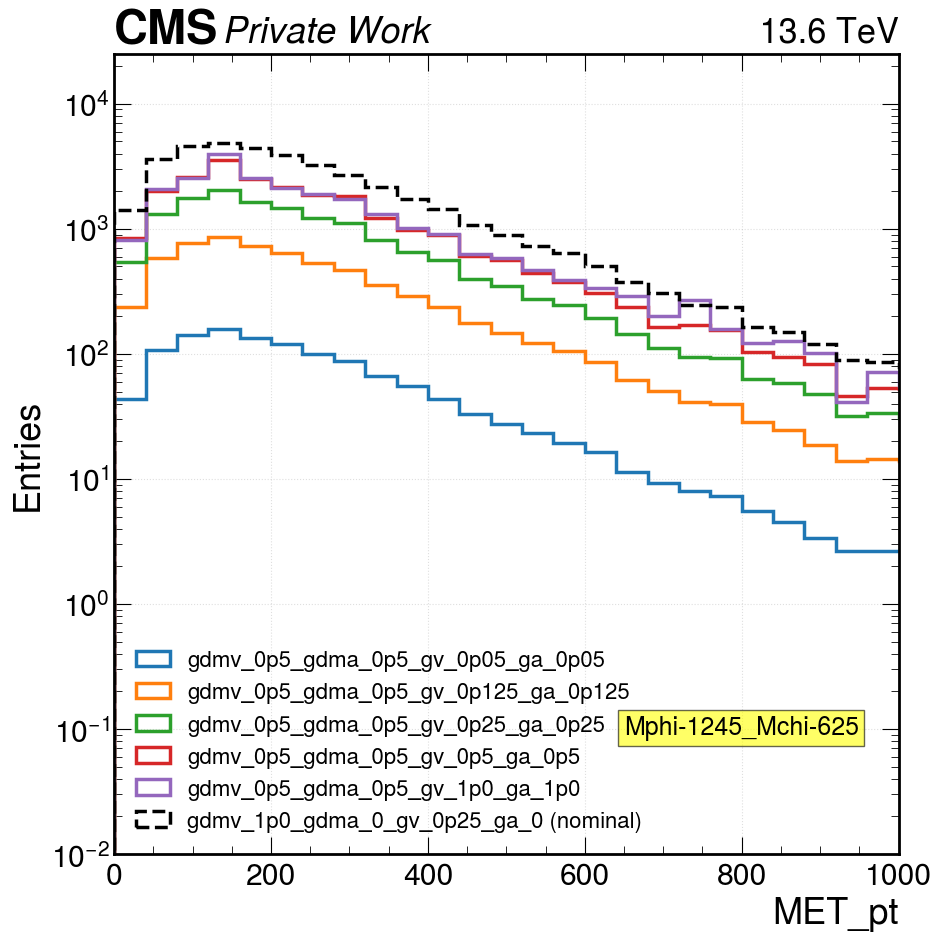

Saved → Mphi-1245_Mchi-625_gdm_0p5_log.png


In [269]:
vari = "MET_pt"
what_couple = 'gdm_0p5'
plot_overlay_reweight(root_files, vari, index_gdm_0p5, mtop_coupling, islog=False, outname=f"Mphi-1245_Mchi-625_{what_couple}.png")
plot_overlay_reweight(root_files, vari, index_gdm_0p5, mtop_coupling, islog=True, outname=f"Mphi-1245_Mchi-625_{what_couple}_log.png")

In [186]:
print('index_only_vector')
print(index_only_vector)

index_only_vector
[0, 1, 2, 3, 4, 5, 6]


In [162]:
print('index only axial')
print(index_only_axial)

index only axial
[7, 8, 9, 10, 11, 12, 13, 14]


In [163]:
print('0p05')
print(index_gdm_0p05)

0p05
[15, 16, 17, 18, 19]


In [164]:
print('0p125')
print(index_gdm_0p125)

0p125
[20, 21, 22, 23, 24]


In [166]:
print('0p25')
print(index_gdm_0p25)

0p25
[25, 26, 27, 28, 29]


In [167]:
print('0p5')
print(index_gdm_0p5)

0p5
[30, 31, 32, 33, 34]
